In [1]:
#!/usr/bin/env python
# coding: utf-8
 
# ============================================================================
# SaaS Customer Churn Prediction & Retention Analytics
# Notebook 2: Churn Prediction Model
# 
# Author: Poorna Venkat Neelakantam
# Dataset: RavenStack SaaS Platform (by River @ Rivalytics)
# Objective: Build, evaluate, and compare ML models to predict customer churn
# ============================================================================

# ============================================================================
# SECTION 1: SETUP & DATA LOADING
# 
# WHY: Load the engineered dataset from Notebook 1. This master table has
# 1 row per account with all original + engineered features ready for modeling.
# ============================================================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
 
# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score,
    accuracy_score, precision_score, recall_score
)
 
# XGBoost
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
    print("✅ XGBoost loaded successfully")
except ImportError:
    HAS_XGBOOST = False
    print("⚠️ XGBoost not installed. Run: pip install xgboost")
    print("   We'll use Gradient Boosting from sklearn instead.")
    from sklearn.ensemble import GradientBoostingClassifier
 
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
 
print("All libraries loaded!")

✅ XGBoost loaded successfully
All libraries loaded!


In [3]:
df = pd.read_csv('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/CSV/master_engineered.csv')
 
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nChurn distribution:")
print(df['churn_label'].value_counts())
print(f"\nChurn rate: {(df['churn_label'] == 'Churned').mean() * 100:.1f}%")

Dataset shape: 748 rows × 49 columns

Churn distribution:
churn_label
Retained    578
Churned     170
Name: count, dtype: int64

Churn rate: 22.7%


# ============================================================================
# SECTION 2: DATA PREPARATION FOR MODELING
# 
# WHY: ML models need numbers, not text. We must:
# 1. Select the right features (drop IDs, leaky columns, text)
# 2. Encode categorical variables (plan_tier, industry → numbers)
# 3. Scale numeric features (MRR in thousands vs satisfaction 1-5 confuses models)
# 4. Split into train/test (80/20, stratified to preserve churn ratio)
# ============================================================================

In [6]:
df['target'] = df['churn_label'].map({'Churned': 1, 'Retained': 0})
 
print(f"Target variable distribution:")
print(f"  Retained (0): {(df['target'] == 0).sum()}")
print(f"  Churned  (1): {(df['target'] == 1).sum()}")
print(f"  Ratio: {df['target'].mean()*100:.1f}% churned")

Target variable distribution:
  Retained (0): 578
  Churned  (1): 170
  Ratio: 22.7% churned


# BUSINESS QUESTION: "Which customer attributes available BEFORE churn
# can we use to predict who will leave next?"
#
# WHY we DROP certain columns:
# - account_id, account_name → identifiers, not predictive
# - churn_flag, churn_label, churn_numeric, target → target variable itself
# - churn_date, reason_code, feedback_text → only known AFTER churn (data leakage!)
# - refund_amount_usd, preceding_upgrade_flag, preceding_downgrade_flag → post-churn
# - is_reactivation → post-churn info

In [8]:
drop_cols = [
    'account_id', 'account_name', 'signup_date',               # Identifiers / dates
    'churn_flag', 'churn_label', 'churn_numeric', 'target',    # Target-related
    'churn_date', 'reason_code', 'feedback_text',              # Post-churn (LEAKAGE!)
    'refund_amount_usd', 'preceding_upgrade_flag',             # Post-churn
    'preceding_downgrade_flag', 'is_reactivation',             # Post-churn
]
# Kept only columns that exist in the dataframe
drop_cols = [col for col in drop_cols if col in df.columns]
 
# Created feature dataframe
feature_df = df.drop(columns=drop_cols, errors='ignore')
 
print(f"Features selected: {feature_df.shape[1]} columns")
print(f"\nFeature columns:")
for i, col in enumerate(feature_df.columns, 1):
    dtype = feature_df[col].dtype
    print(f"  {i:2d}. {col:<35s} ({dtype})")
 

Features selected: 36 columns

Feature columns:
   1. industry                            (object)
   2. country                             (object)
   3. referral_source                     (object)
   4. plan_tier                           (object)
   5. seats                               (int64)
   6. is_trial                            (bool)
   7. subscription_count                  (int64)
   8. latest_mrr                          (int64)
   9. latest_arr                          (int64)
  10. had_upgrade                         (int64)
  11. had_downgrade                       (int64)
  12. billing_frequency                   (object)
  13. auto_renew                          (int64)
  14. distinct_features_used              (int64)
  15. total_usage_count                   (int64)
  16. avg_usage_duration_secs             (float64)
  17. total_errors                        (int64)
  18. beta_feature_events                 (int64)
  19. total_tickets                       (int

In [9]:
# We use LabelEncoder for ordinal categories and pd.get_dummies for nominal ones.
 
print("=== ENCODING CATEGORICAL VARIABLES ===\n")
 
# Identify categorical columns
cat_cols = feature_df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")
 
# For each categorical column, show unique values
for col in cat_cols:
    print(f"\n  {col}: {feature_df[col].nunique()} unique → {feature_df[col].unique()[:10]}")
 
# One-Hot Encode (creates dummy columns, avoids false ordinal relationships)
feature_encoded = pd.get_dummies(feature_df, columns=cat_cols, drop_first=True, dtype=int)
 
print(f"\nShape after encoding: {feature_encoded.shape}")
print(f"New columns created: {feature_encoded.shape[1] - feature_df.shape[1] + len(cat_cols)}")
 

=== ENCODING CATEGORICAL VARIABLES ===

Categorical columns to encode: ['industry', 'country', 'referral_source', 'plan_tier', 'is_trial', 'billing_frequency']

  industry: 5 unique → ['HealthTech' 'Cybersecurity' 'EdTech' 'DevTools' 'FinTech']

  country: 7 unique → ['US' 'IN' 'CA' 'UK' 'AU' 'DE' 'FR']

  referral_source: 5 unique → ['event' 'partner' 'organic' 'ads' 'other']

  plan_tier: 3 unique → ['Enterprise' 'Basic' 'Pro']

  is_trial: 2 unique → [False  True]

  billing_frequency: 2 unique → ['monthly' 'annual']

Shape after encoding: (748, 48)
New columns created: 18


In [10]:
# Filling any remaining NaN with 0
feature_encoded = feature_encoded.fillna(0)
 
# Replacing  infinity values
feature_encoded = feature_encoded.replace([np.inf, -np.inf], 0)
 
print(f"Remaining NaNs: {feature_encoded.isnull().sum().sum()}")
print(f"Infinity values: {np.isinf(feature_encoded.values).sum()}")
print(f"\nFinal feature matrix: {feature_encoded.shape}")
 

Remaining NaNs: 0
Infinity values: 0

Final feature matrix: (748, 48)


# WHY: We split 80% train / 20% test with STRATIFICATION.
# Stratification ensures both sets have ~22% churn (same ratio as full data).
# Without it, the test set might get 10% or 35% churn by random chance,
# giving misleading evaluation results.

In [11]:
X = feature_encoded
y = df['target']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
 
print(f"Training set: {X_train.shape[0]} samples ({y_train.mean()*100:.1f}% churn)")
print(f"Test set:     {X_test.shape[0]} samples ({y_test.mean()*100:.1f}% churn)")
print(f"Features:     {X_train.shape[1]}")

Training set: 598 samples (22.7% churn)
Test set:     150 samples (22.7% churn)
Features:     48


# WHY: Features like MRR ($0-$33,000) and satisfaction (1-5) are on wildly 
# different scales. Logistic Regression is sensitive to this — it would give 
# MRR way too much influence just because its numbers are bigger.
# StandardScaler makes mean=0, std=1 for all features.


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)    # FIT + transform on train
X_test_scaled = scaler.transform(X_test)           # ONLY transform on test
 
# Convert back to DataFrame for feature names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
 
print("✅ Features scaled (StandardScaler)")
print(f"   Train mean sample: {X_train_scaled.iloc[0, :3].values.round(2)}")
print(f"   (Should be around -1 to +1 range)")

✅ Features scaled (StandardScaler)
   Train mean sample: [0.96 0.01 0.09]
   (Should be around -1 to +1 range)


# ============================================================================
# SECTION 3: MODEL TRAINING
# 
# WHY: We train 3 different models and compare them. Each has strengths:
# - Logistic Regression: Simple, interpretable, great baseline
# - Random Forest: Handles non-linear patterns, resistant to outliers
# - XGBoost: State-of-the-art for tabular data, wins most competitions
#

#  Model 1 — Logistic Regression (Baseline)
 
# BUSINESS QUESTION: "Can we build a simple, interpretable model that predicts
# which customers are likely to churn, and what are the key drivers?"
#
# WHY LOGISTIC REGRESSION FIRST:
# - It's the industry standard baseline for binary classification
# - Highly interpretable (coefficients tell you direction + strength)
# - Interviewers expect you to start simple before going complex
# - If LR gets 0.85 AUC, you may not even need XGBoost

In [15]:
print("=" * 60)
print("MODEL 1: LOGISTIC REGRESSION (Baseline)")
print("=" * 60)
 
lr_model = LogisticRegression(
    max_iter=1000,          # enough iterations to converge
    random_state=42,
    class_weight='balanced' # handles 22% vs 78% imbalance automatically
)
 
lr_model.fit(X_train_scaled, y_train)
 
# Predictions
lr_pred = lr_model.predict(X_test_scaled)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]  # probability of churn
 
print(f"\nAccuracy:  {accuracy_score(y_test, lr_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, lr_pred)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, lr_pred)*100:.2f}%")
print(f"F1 Score:  {f1_score(y_test, lr_pred)*100:.2f}%")
print(f"ROC AUC:   {roc_auc_score(y_test, lr_pred_proba):.4f}")
 
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Retained', 'Churned']))

MODEL 1: LOGISTIC REGRESSION (Baseline)

Accuracy:  66.67%
Precision: 35.71%
Recall:    58.82%
F1 Score:  44.44%
ROC AUC:   0.6491

Classification Report:
              precision    recall  f1-score   support

    Retained       0.85      0.69      0.76       116
     Churned       0.36      0.59      0.44        34

    accuracy                           0.67       150
   macro avg       0.60      0.64      0.60       150
weighted avg       0.74      0.67      0.69       150



#  Model 2 — Random Forest 
 
# BUSINESS QUESTION: "Can a more complex model that captures non-linear patterns
# outperform our logistic regression baseline?"
#
# WHY RANDOM FOREST:
# - Captures non-linear relationships (e.g., churn spikes only above 5 tickets)
# - Built-in feature importance ranking
# - Resistant to outliers (tree-based, not distance-based)
# - No scaling needed (but we use scaled data for consistency)

In [16]:
print("=" * 60)
print("MODEL 2: RANDOM FOREST")
print("=" * 60)
 
rf_model = RandomForestClassifier(
    n_estimators=200,       # 200 trees in the forest
    max_depth=10,           # prevent overfitting
    min_samples_split=5,    # minimum samples to split a node
    min_samples_leaf=3,     # minimum samples in a leaf
    class_weight='balanced',# handles class imbalance
    random_state=42,
    n_jobs=-1               # use all CPU cores
)
 
rf_model.fit(X_train_scaled, y_train)
 
rf_pred = rf_model.predict(X_test_scaled)
rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
 
print(f"\nAccuracy:  {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, rf_pred)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, rf_pred)*100:.2f}%")
print(f"F1 Score:  {f1_score(y_test, rf_pred)*100:.2f}%")
print(f"ROC AUC:   {roc_auc_score(y_test, rf_pred_proba):.4f}")
 
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Retained', 'Churned']))

MODEL 2: RANDOM FOREST

Accuracy:  84.67%
Precision: 92.31%
Recall:    35.29%
F1 Score:  51.06%
ROC AUC:   0.8573

Classification Report:
              precision    recall  f1-score   support

    Retained       0.84      0.99      0.91       116
     Churned       0.92      0.35      0.51        34

    accuracy                           0.85       150
   macro avg       0.88      0.67      0.71       150
weighted avg       0.86      0.85      0.82       150



# ---  Model 3 — XGBoost (State of the Art) ---
 
# BUSINESS QUESTION: "Can the most powerful tabular ML algorithm give us even
# better predictions, and what does it reveal about churn drivers?"
#
# WHY XGBOOST:
# - Consistently wins Kaggle competitions for tabular/structured data
# - Gradient boosting = builds trees sequentially, each fixing previous errors
# - Has built-in regularization to prevent overfitting
# - scale_pos_weight handles our 22% churn imbalance
 

In [17]:
print("=" * 60)
print("MODEL 3: XGBOOST (State-of-the-Art)")
print("=" * 60)
 
# Calculate imbalance ratio for scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_ratio = neg_count / pos_count
 
if HAS_XGBOOST:
    xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,              # use 80% of data per tree (reduces overfitting)
        colsample_bytree=0.8,       # use 80% of features per tree
        scale_pos_weight=scale_ratio,# handles class imbalance
        random_state=42,
        eval_metric='auc',
        use_label_encoder=False
    )
else:
    xgb_model = GradientBoostingClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    )
    print("(Using sklearn GradientBoosting as XGBoost fallback)\n")
 
xgb_model.fit(X_train_scaled, y_train)
 
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
 
print(f"\nAccuracy:  {accuracy_score(y_test, xgb_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, xgb_pred)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, xgb_pred)*100:.2f}%")
print(f"F1 Score:  {f1_score(y_test, xgb_pred)*100:.2f}%")
print(f"ROC AUC:   {roc_auc_score(y_test, xgb_pred_proba):.4f}")
 
print(f"\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Retained', 'Churned']))

MODEL 3: XGBOOST (State-of-the-Art)

Accuracy:  80.67%
Precision: 60.87%
Recall:    41.18%
F1 Score:  49.12%
ROC AUC:   0.8296

Classification Report:
              precision    recall  f1-score   support

    Retained       0.84      0.92      0.88       116
     Churned       0.61      0.41      0.49        34

    accuracy                           0.81       150
   macro avg       0.73      0.67      0.69       150
weighted avg       0.79      0.81      0.79       150



# ============================================================================
# SECTION 4: MODEL COMPARISON
# 
# WHY: Comparing all 3 models side-by-side lets us pick the best one AND
# explain to stakeholders why we chose it. This is the "which model do we 
# deploy?" decision that real data teams make.
# ============================================================================

# ---  Model Comparison Table ---
 
# BUSINESS QUESTION: "Which model should we deploy in production for our 
# churn early warning system?"

In [18]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    'ROC AUC': [
        roc_auc_score(y_test, lr_pred_proba),
        roc_auc_score(y_test, rf_pred_proba),
        roc_auc_score(y_test, xgb_pred_proba)
    ]
})
 
# Format as percentages
for col in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']:
    results[col] = results[col].apply(lambda x: f'{x*100:.2f}%')
 
print("=" * 70)
print("MODEL COMPARISON — ALL 3 MODELS")
print("=" * 70)
print(results.to_string(index=False))
 
# Highlight best model
best_auc = max(
    roc_auc_score(y_test, lr_pred_proba),
    roc_auc_score(y_test, rf_pred_proba),
    roc_auc_score(y_test, xgb_pred_proba)
)
best_model_name = ['Logistic Regression', 'Random Forest', 'XGBoost'][
    [roc_auc_score(y_test, lr_pred_proba),
     roc_auc_score(y_test, rf_pred_proba),
     roc_auc_score(y_test, xgb_pred_proba)].index(best_auc)
]
 
print(f"\n🏆 BEST MODEL: {best_model_name} (AUC: {best_auc*100:.2f}%)")

MODEL COMPARISON — ALL 3 MODELS
              Model Accuracy Precision Recall F1 Score ROC AUC
Logistic Regression   66.67%    35.71% 58.82%   44.44%  64.91%
      Random Forest   84.67%    92.31% 35.29%   51.06%  85.73%
            XGBoost   80.67%    60.87% 41.18%   49.12%  82.96%

🏆 BEST MODEL: Random Forest (AUC: 85.73%)


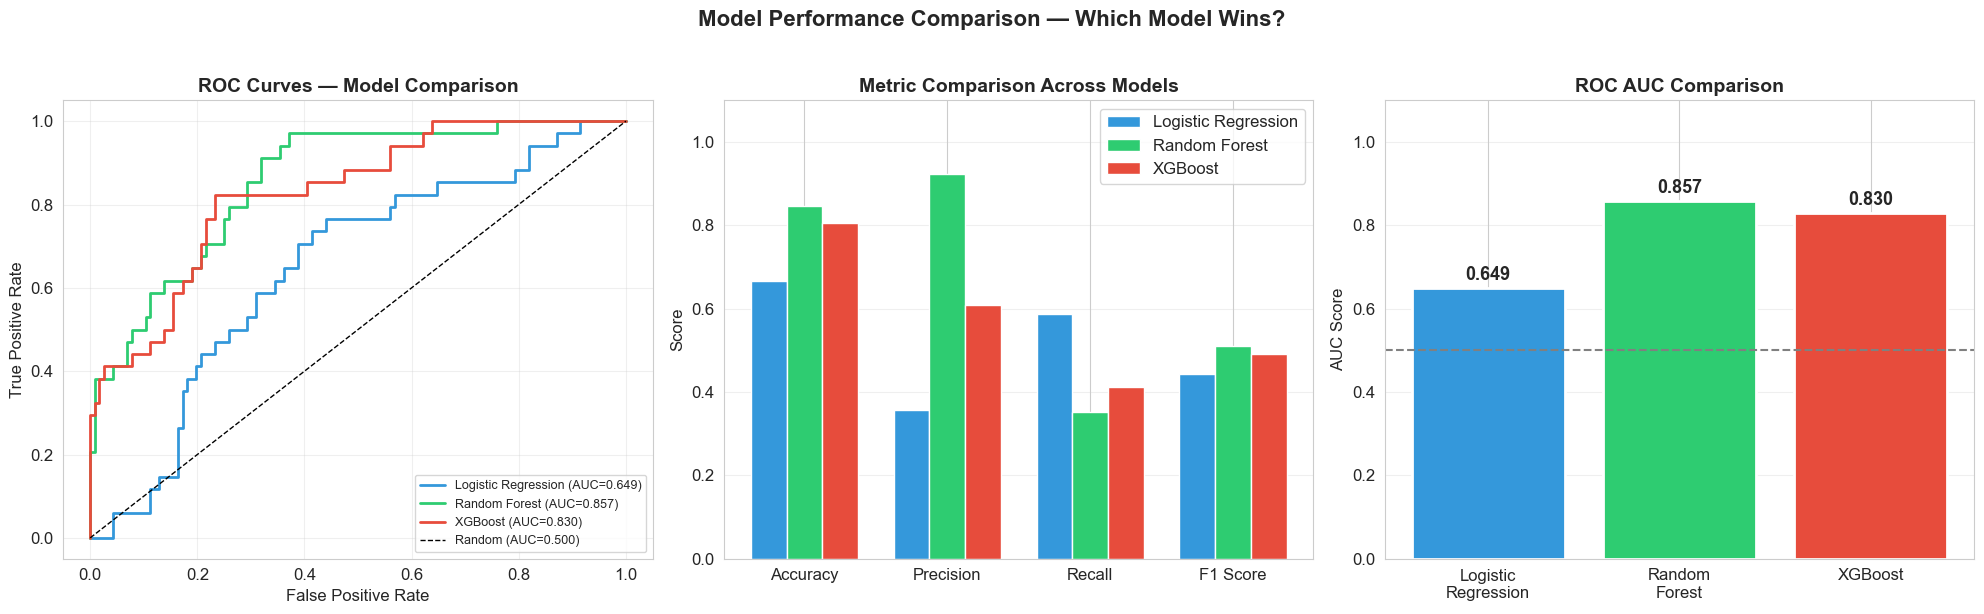

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
 
# 1. ROC Curves — All 3 models
ax = axes[0]
for name, proba, color in [
    ('Logistic Regression', lr_pred_proba, '#3498db'),
    ('Random Forest', rf_pred_proba, '#2ecc71'),
    ('XGBoost', xgb_pred_proba, '#e74c3c')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')
 
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
 
# 2. Metric Comparison Bar Chart
ax = axes[1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.25
 
lr_vals = [accuracy_score(y_test, lr_pred), precision_score(y_test, lr_pred),
           recall_score(y_test, lr_pred), f1_score(y_test, lr_pred)]
rf_vals = [accuracy_score(y_test, rf_pred), precision_score(y_test, rf_pred),
           recall_score(y_test, rf_pred), f1_score(y_test, rf_pred)]
xgb_vals = [accuracy_score(y_test, xgb_pred), precision_score(y_test, xgb_pred),
            recall_score(y_test, xgb_pred), f1_score(y_test, xgb_pred)]
 
bars1 = ax.bar(x - width, lr_vals, width, label='Logistic Regression', color='#3498db')
bars2 = ax.bar(x, rf_vals, width, label='Random Forest', color='#2ecc71')
bars3 = ax.bar(x + width, xgb_vals, width, label='XGBoost', color='#e74c3c')
 
ax.set_ylabel('Score')
ax.set_title('Metric Comparison Across Models', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')
 
# 3. AUC Comparison
ax = axes[2]
aucs = [roc_auc_score(y_test, lr_pred_proba),
        roc_auc_score(y_test, rf_pred_proba),
        roc_auc_score(y_test, xgb_pred_proba)]
colors = ['#3498db', '#2ecc71', '#e74c3c']
model_names = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
 
bars = ax.bar(model_names, aucs, color=colors, edgecolor='white', linewidth=2)
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{auc:.3f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
 
ax.set_ylabel('AUC Score')
ax.set_title('ROC AUC Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color='gray', linestyle='--', label='Random baseline')
ax.grid(True, alpha=0.3, axis='y')
 
plt.suptitle('Model Performance Comparison — Which Model Wins?',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/dashboards/12_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# ============================================================================
# SECTION 5: CONFUSION MATRICES
# 
# WHY: The confusion matrix shows EXACTLY where each model gets it right
# and wrong. For churn prediction, we care most about:
# - True Positives (correctly predicted churners) → we can save them!
# - False Negatives (missed churners) → COSTLY, these customers leave unnoticed
# - False Positives (flagged but didn't churn) → some wasted outreach, but OK
# ============================================================================

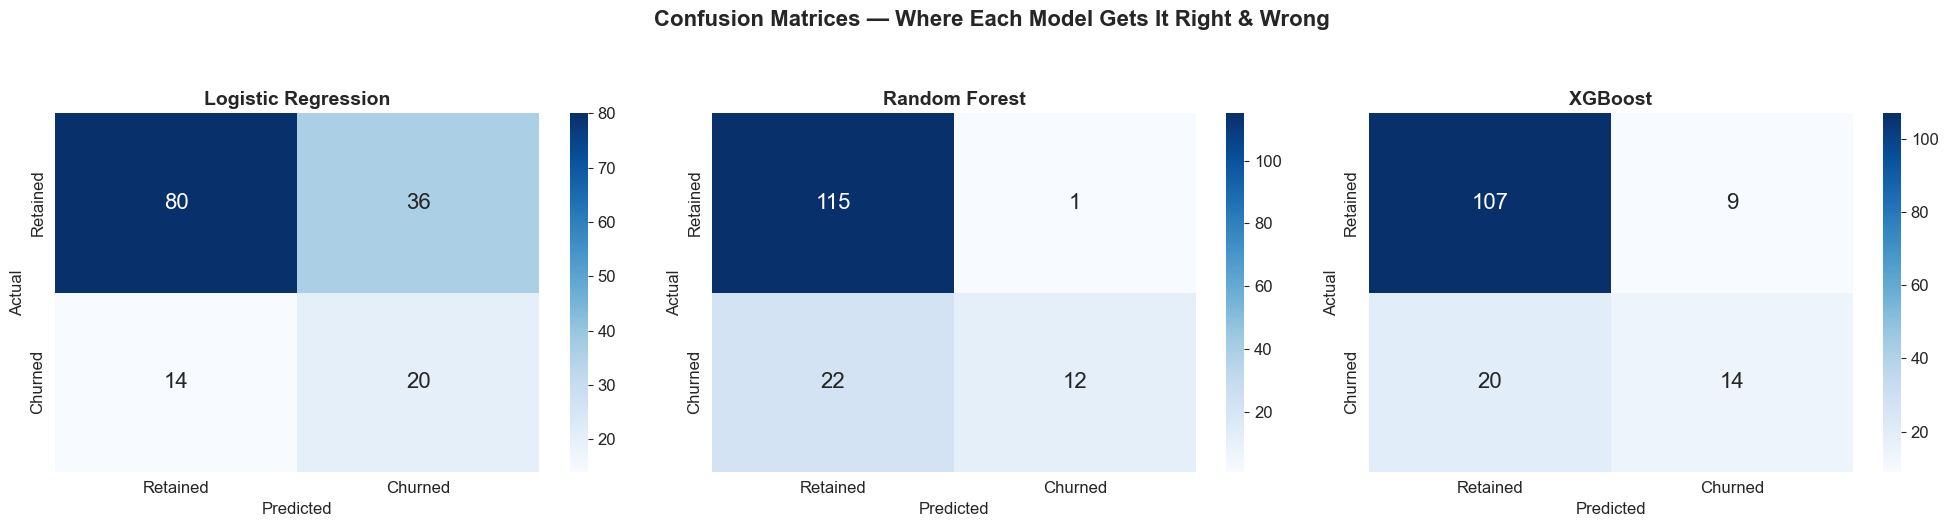


Logistic Regression:
  ✅ Correctly identified 20 churners out of 34 actual churners (58.8% caught)
  ❌ Missed 14 churners (they left without us knowing)
  ⚠️ False alarms: 36 (flagged but didn't churn — some wasted outreach)

Random Forest:
  ✅ Correctly identified 12 churners out of 34 actual churners (35.3% caught)
  ❌ Missed 22 churners (they left without us knowing)
  ⚠️ False alarms: 1 (flagged but didn't churn — some wasted outreach)

XGBoost:
  ✅ Correctly identified 14 churners out of 34 actual churners (41.2% caught)
  ❌ Missed 20 churners (they left without us knowing)
  ⚠️ False alarms: 9 (flagged but didn't churn — some wasted outreach)


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
 
for ax, pred, name in zip(axes,
    [lr_pred, rf_pred, xgb_pred],
    ['Logistic Regression', 'Random Forest', 'XGBoost']):
    
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'],
                annot_kws={'size': 16})
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_title(f'{name}', fontsize=14, fontweight='bold')
 
plt.suptitle('Confusion Matrices — Where Each Model Gets It Right & Wrong',
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/dashboards/13_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
 
# Print interpretation
for pred, name in zip([lr_pred, rf_pred, xgb_pred],
                      ['Logistic Regression', 'Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{name}:")
    print(f"  ✅ Correctly identified {tp} churners out of {tp+fn} actual churners ({tp/(tp+fn)*100:.1f}% caught)")
    print(f"  ❌ Missed {fn} churners (they left without us knowing)")
    print(f"  ⚠️ False alarms: {fp} (flagged but didn't churn — some wasted outreach)")

# ============================================================================
# SECTION 6: FEATURE IMPORTANCE
# 
# WHY: This is THE MOST VALUABLE output for the business. It answers:
# "WHAT drives churn?" Not just "who will churn" but WHY.
# This directly feeds your business recommendations.
#
# BUSINESS QUESTION: "What are the top factors causing customers to leave,
# and which ones can we actually influence to reduce churn?"
# ============================================================================

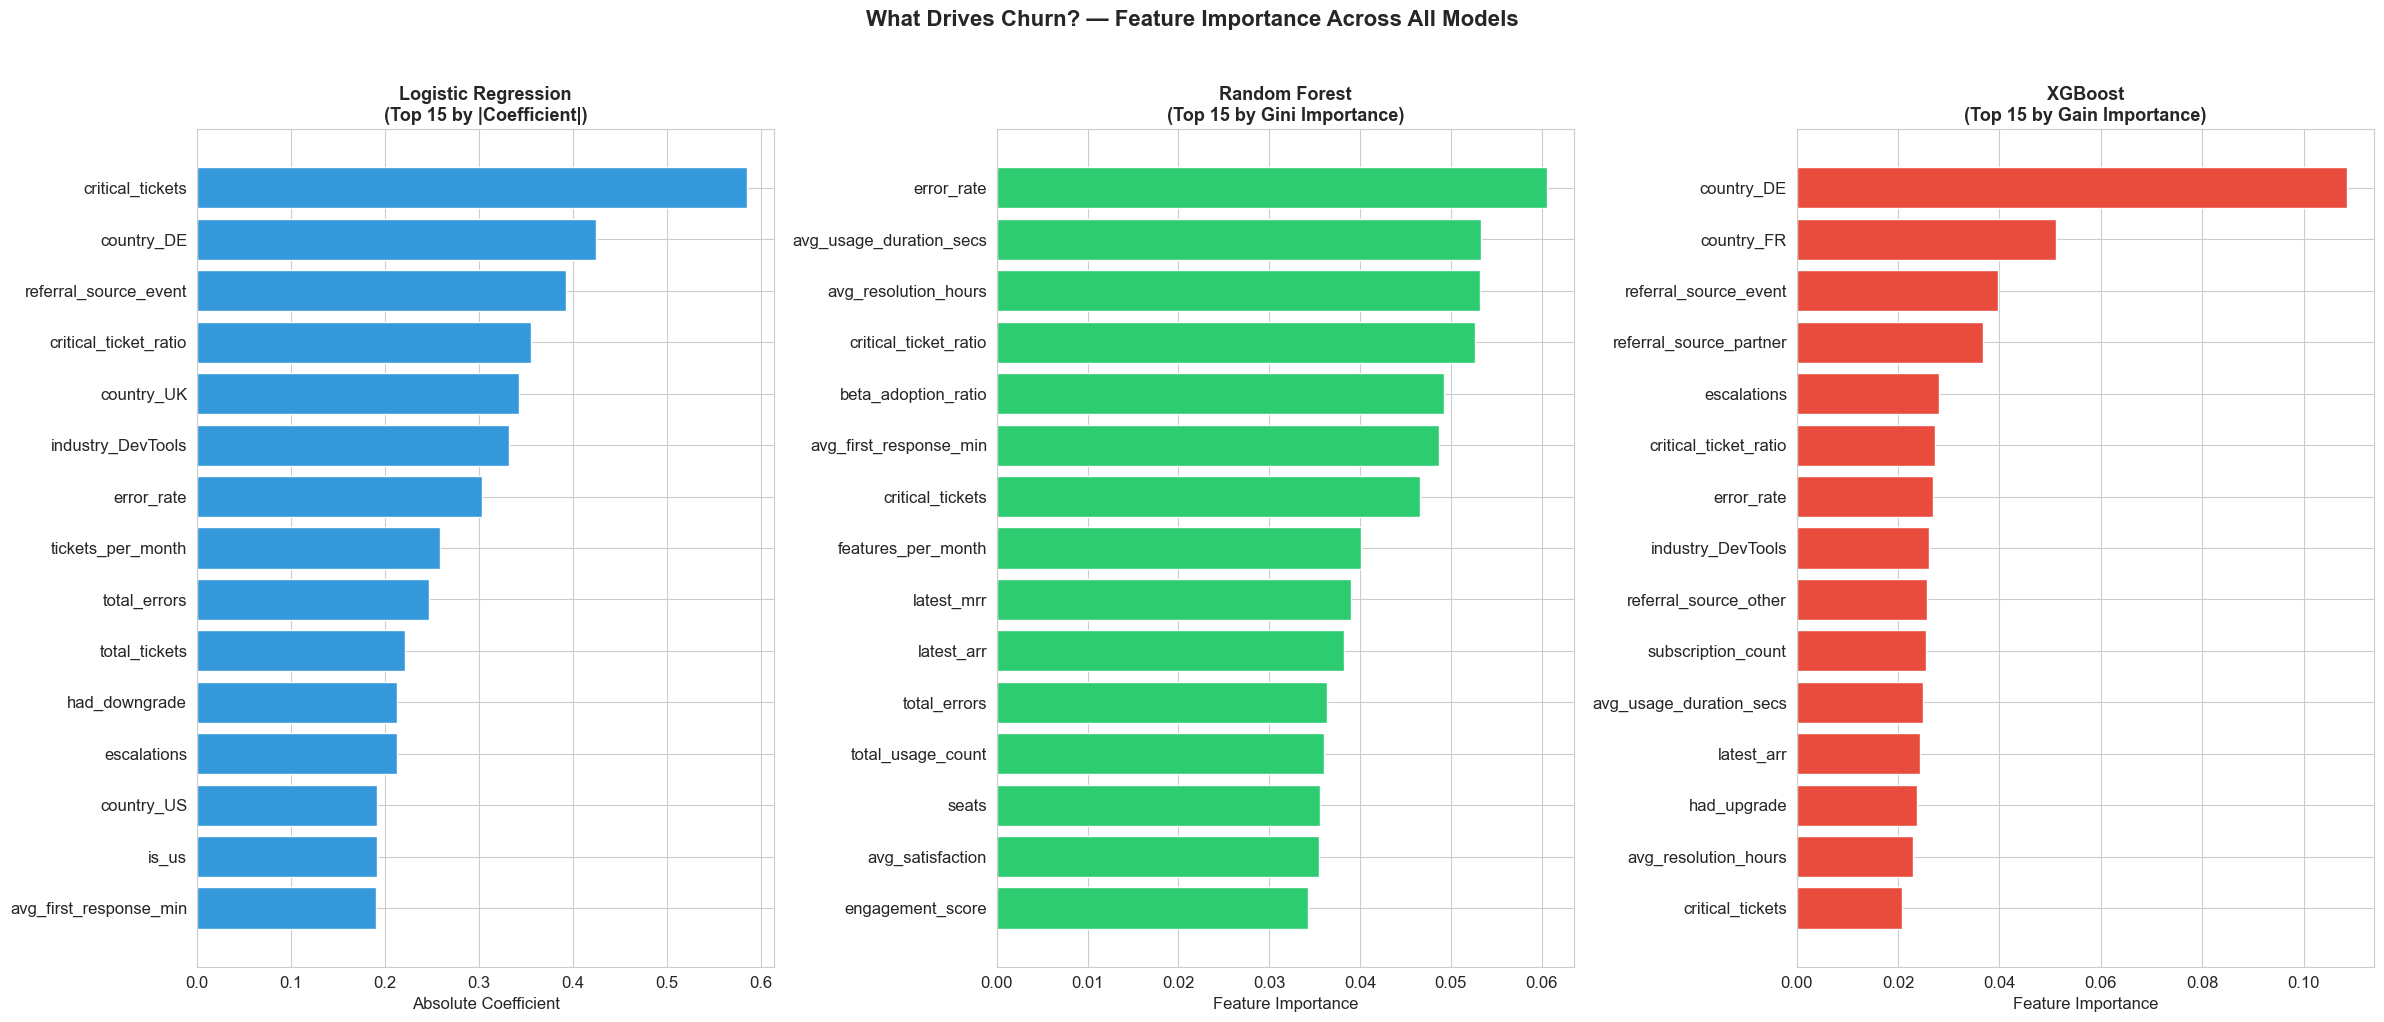

TOP 10 CHURN DRIVERS (from Random Forest)
  # 1  error_rate                           0.0606
  # 2  avg_usage_duration_secs              0.0534
  # 3  avg_resolution_hours                 0.0532
  # 4  critical_ticket_ratio                0.0526
  # 5  beta_adoption_ratio                  0.0492
  # 6  avg_first_response_min               0.0487
  # 7  critical_tickets                     0.0466
  # 8  features_per_month                   0.0401
  # 9  latest_mrr                           0.0390
  #10  latest_arr                           0.0382


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(24, 10))
 
# 1. Logistic Regression — Coefficients
lr_importance = pd.Series(
    np.abs(lr_model.coef_[0]), index=X_train.columns
).sort_values(ascending=True).tail(15)
 
axes[0].barh(lr_importance.index, lr_importance.values, color='#3498db')
axes[0].set_title('Logistic Regression\n(Top 15 by |Coefficient|)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Absolute Coefficient')
 
# 2. Random Forest — Feature Importance
rf_importance = pd.Series(
    rf_model.feature_importances_, index=X_train.columns
).sort_values(ascending=True).tail(15)
 
axes[1].barh(rf_importance.index, rf_importance.values, color='#2ecc71')
axes[1].set_title('Random Forest\n(Top 15 by Gini Importance)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Feature Importance')
 
# 3. XGBoost — Feature Importance
xgb_importance = pd.Series(
    xgb_model.feature_importances_, index=X_train.columns
).sort_values(ascending=True).tail(15)
 
axes[2].barh(xgb_importance.index, xgb_importance.values, color='#e74c3c')
axes[2].set_title('XGBoost\n(Top 15 by Gain Importance)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Feature Importance')
 
plt.suptitle('What Drives Churn? — Feature Importance Across All Models',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/dashboards/14_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
 
# Print top 10 features from best model
print("=" * 60)
print(f"TOP 10 CHURN DRIVERS (from {best_model_name})")
print("=" * 60)
 
if best_model_name == 'XGBoost':
    top_features = xgb_importance.tail(10).sort_values(ascending=False)
elif best_model_name == 'Random Forest':
    top_features = rf_importance.tail(10).sort_values(ascending=False)
else:
    top_features = lr_importance.tail(10).sort_values(ascending=False)
 
for rank, (feature, importance) in enumerate(top_features.items(), 1):
    print(f"  #{rank:2d}  {feature:<35s}  {importance:.4f}")

# ============================================================================
# SECTION 7: CROSS-VALIDATION
# 
# WHY: A single train/test split can be lucky or unlucky. Cross-validation
# tests the model on 5 different splits and averages the results — giving 
# a much more reliable performance estimate.
#

In [22]:
print("=" * 60)
print("5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 60)
 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
for name, model in [('Logistic Regression', lr_model),
                     ('Random Forest', rf_model),
                     ('XGBoost', xgb_model)]:
    
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    print(f"\n{name}:")
    print(f"  AUC scores: {[f'{s:.3f}' for s in cv_scores]}")
    print(f"  Mean AUC:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
 

5-FOLD STRATIFIED CROSS-VALIDATION

Logistic Regression:
  AUC scores: ['0.575', '0.598', '0.622', '0.668', '0.563']
  Mean AUC:   0.6052 ± 0.0374

Random Forest:
  AUC scores: ['0.814', '0.832', '0.867', '0.845', '0.747']
  Mean AUC:   0.8208 ± 0.0407

XGBoost:
  AUC scores: ['0.853', '0.850', '0.895', '0.795', '0.767']
  Mean AUC:   0.8322 ± 0.0455


# ============================================================================
# SECTION 8: GENERATE AT-RISK CUSTOMER LIST
# 
# WHY: The whole point of prediction is ACTION. We generate a ranked list
# of currently active customers sorted by churn probability. The Customer 
# Success team uses this to prioritize outreach.
#
# BUSINESS QUESTION: "Give me a list of our top 50 at-risk customers ranked 
# by churn probability so our CS team can start retention outreach this week."
# ============================================================================

In [26]:

if best_model_name == 'XGBoost':
    best_model = xgb_model
elif best_model_name == 'Random Forest':
    best_model = rf_model
else:
    best_model = lr_model
 
# Scale all features
X_all_scaled = scaler.transform(X)
 
# Predict probabilities
all_proba = best_model.predict_proba(X_all_scaled)[:, 1]
 
# Create at-risk table
at_risk = df[['account_id', 'account_name', 'industry', 'plan_tier', 
               'seats', 'churn_label']].copy()
 
# Only include columns that exist
for col in ['latest_mrr', 'total_tickets', 'avg_satisfaction', 'engagement_score', 'tenure_months']:
    if col in df.columns:
        at_risk[col] = df[col].values
 
at_risk['churn_probability'] = (all_proba * 100).round(2)
 
at_risk['risk_level'] = pd.cut(
    at_risk['churn_probability'],
    bins=[0, 25, 50, 75, 100],
    labels=['Low', 'Medium', 'High', 'Critical']
)
 
# Sort by churn probability (highest first)
at_risk = at_risk.sort_values('churn_probability', ascending=False)

In [28]:
print("=" * 70)
print(f"TOP 20 AT-RISK ACTIVE CUSTOMERS (scored by {best_model_name})")
print("=" * 70)
 
# Filter to active customers only (not already churned)
active_at_risk = at_risk[at_risk['churn_label'] == 'Retained'].head(20)
print(active_at_risk.to_string(index=False))
 
print(f"\n Risk Distribution (Active Customers Only):")
active_only = at_risk[at_risk['churn_label'] == 'Retained']
print(active_only['risk_level'].value_counts().sort_index().to_string())
 
if 'latest_mrr' in active_only.columns:
    print(f"\n💰 MRR at Risk by Level:")
    mrr_at_risk = active_only.groupby('risk_level')['latest_mrr'].sum().sort_index()
    for level, mrr in mrr_at_risk.items():
        print(f"  {level:10s}: ${mrr:,.0f}")

TOP 20 AT-RISK ACTIVE CUSTOMERS (scored by Random Forest)
account_id account_name      industry  plan_tier  seats churn_label  latest_mrr  total_tickets  avg_satisfaction  engagement_score  tenure_months  churn_probability risk_level
  A-f97b9a  Company_159       FinTech        Pro     16    Retained        7164              7              1.57            0.6174             32              58.70       High
  A-068fc6  Company_465        EdTech Enterprise     35    Retained        6965              5              2.60            0.6117             31              47.48     Medium
  A-7f29a7  Company_386 Cybersecurity      Basic     41    Retained        8159              1              4.00            0.4371              0              47.23     Medium
  A-c37cab  Company_278 Cybersecurity        Pro     13    Retained       19502              4              3.75            0.5654              2              46.73     Medium
  A-c37cab  Company_278 Cybersecurity        Pro     13    Ret

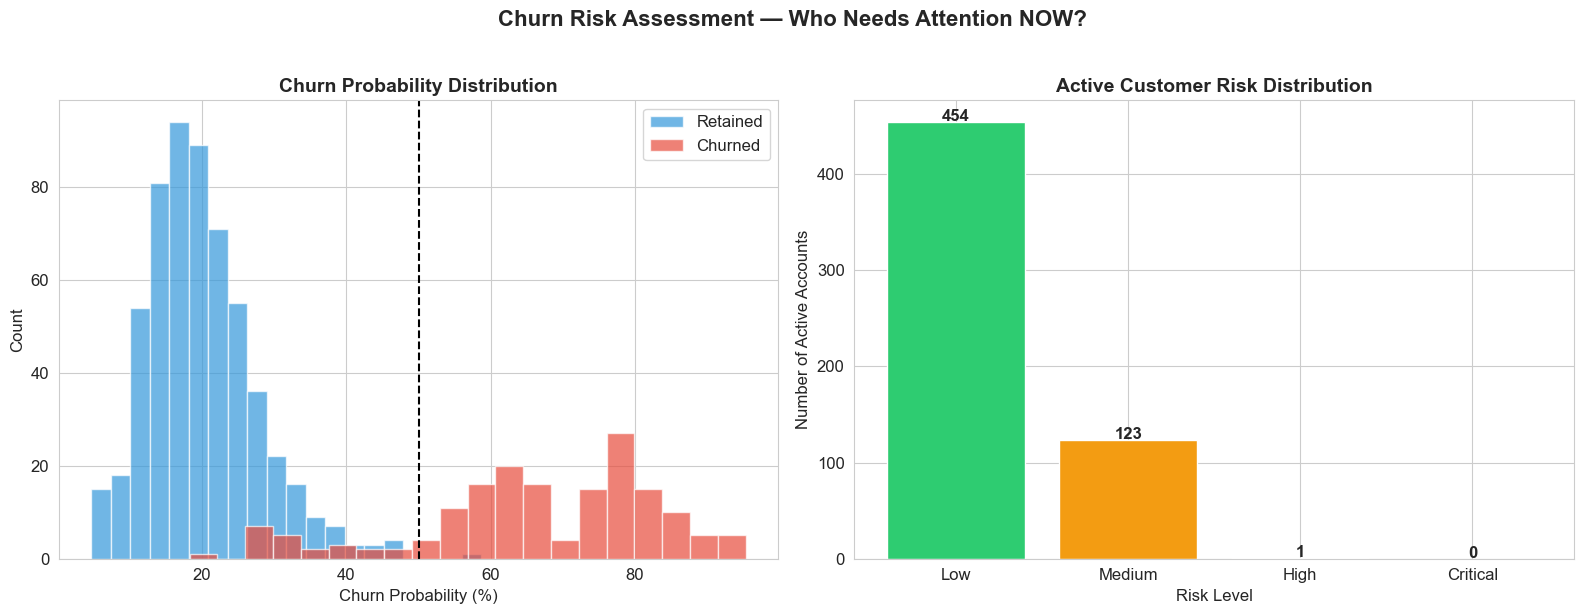

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# 1. Churn probability distribution
axes[0].hist(at_risk[at_risk['churn_label'] == 'Retained']['churn_probability'],
             bins=20, color='#3498db', edgecolor='white', alpha=0.7, label='Retained')
axes[0].hist(at_risk[at_risk['churn_label'] == 'Churned']['churn_probability'],
             bins=20, color='#e74c3c', edgecolor='white', alpha=0.7, label='Churned')
axes[0].set_xlabel('Churn Probability (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Churn Probability Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].axvline(x=50, color='black', linestyle='--', label='50% threshold')
 
# 2. Risk level distribution (active only)
risk_counts = active_only['risk_level'].value_counts().sort_index()
risk_colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e67e22', 'Critical': '#e74c3c'}
axes[1].bar(risk_counts.index, risk_counts.values,
            color=[risk_colors.get(x, '#3498db') for x in risk_counts.index])
axes[1].set_xlabel('Risk Level')
axes[1].set_ylabel('Number of Active Accounts')
axes[1].set_title('Active Customer Risk Distribution', fontsize=14, fontweight='bold')
for i, v in enumerate(risk_counts.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=12, fontweight='bold')
 
plt.suptitle('Churn Risk Assessment — Who Needs Attention NOW?',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/dashboards', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
at_risk.to_csv('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/CSV/at_risk_customers.csv', index=False)
print("✅ Saved: data/processed/at_risk_customers.csv")
 
# 2. Model comparison results
results.to_csv('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/CSV/model_comparison.csv', index=False)
print("✅ Saved: data/processed/model_comparison.csv")
 
# 3. Feature importance (best model)
if best_model_name == 'XGBoost':
    fi = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
elif best_model_name == 'Random Forest':
    fi = pd.Series(rf_model.feature_importances_, index=X_train.columns)
else:
    fi = pd.Series(np.abs(lr_model.coef_[0]), index=X_train.columns)
 
fi.sort_values(ascending=False).to_csv('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/CSV/feature_importance.csv', header=['importance'])
print("✅ Saved: data/processed/feature_importance.csv")
 
print(f"\n{'='*60}")
print("PHASE 3 COMPLETE — ML PREDICTION MODEL")
print(f"{'='*60}")
print(f"""
📊 Summary:
   - 3 models trained and compared
   - Best model: {best_model_name} (AUC: {best_auc*100:.2f}%)
   - {len(active_at_risk)} high-risk active customers identified
   - Top churn drivers identified via feature importance
   
📁 Files generated:
   - dashboards/12_model_comparison.png
   - dashboards/13_confusion_matrices.png
   - dashboards/14_feature_importance.png
   - dashboards/15_at_risk_customers.png
   - data/processed/at_risk_customers.csv
   - data/processed/model_comparison.csv
   - data/processed/feature_importance.csv""")

✅ Saved: data/processed/at_risk_customers.csv
✅ Saved: data/processed/model_comparison.csv
✅ Saved: data/processed/feature_importance.csv

PHASE 3 COMPLETE — ML PREDICTION MODEL

📊 Summary:
   - 3 models trained and compared
   - Best model: Random Forest (AUC: 85.73%)
   - 20 high-risk active customers identified
   - Top churn drivers identified via feature importance
   
📁 Files generated:
   - dashboards/12_model_comparison.png
   - dashboards/13_confusion_matrices.png
   - dashboards/14_feature_importance.png
   - dashboards/15_at_risk_customers.png
   - data/processed/at_risk_customers.csv
   - data/processed/model_comparison.csv
   - data/processed/feature_importance.csv
